# Probando cosas

In [7]:
import pandas as pd
import os

DATASETS_DIR = "datasets"
CSV_FINAL = os.path.join(DATASETS_DIR, "replays_subset_with_time_percentages.csv")

df_model = pd.read_csv(CSV_FINAL, low_memory=False)

print("Shape del dataset final:", df_model.shape)
display(df_model.head())

Shape del dataset final: (10000, 107)


,blue.color,blue.stats.ball.possession_time,blue.stats.ball.time_in_side,blue.stats.boost.amount_collected,blue.stats.boost.amount_collected_big,blue.stats.boost.amount_collected_small,blue.stats.boost.amount_overfill,blue.stats.boost.amount_overfill_stolen,blue.stats.boost.amount_stolen,blue.stats.boost.amount_stolen_big,...,orange.stats.positioning.time_behind_ball,orange.stats.positioning.time_defensive_half,orange.stats.positioning.time_defensive_third,orange.stats.positioning.time_infront_ball,orange.stats.positioning.time_neutral_third,orange.stats.positioning.time_offensive_half,orange.stats.positioning.time_offensive_third,overtime,overtime_seconds,server.region
0,blue,44.282927,39.068293,2506,2110,396,289,30,516,369,...,162.912195,128.600000,96.702434,34.546341,57.858537,68.853659,42.887805,False,0.0,USE
1,blue,40.938907,69.038585,3835,2788,1047,588,76,663,427,...,162.025730,106.874598,66.543408,36.411576,82.903543,91.562701,48.987138,False,0.0,USE
2,blue,31.317919,43.644509,5306,3816,1490,403,32,1103,654,...,143.297688,135.034682,97.141618,56.421965,68.057803,64.684971,34.523121,False,0.0,USE
3,blue,36.722500,36.790000,4858,3752,1106,618,251,1148,868,...,150.320000,134.945000,107.170000,47.282500,55.260002,62.655000,35.170000,False,0.0,EU
4,blue,38.622642,49.783019,1281,1006,275,405,38,188,167,...,171.433962,119.905666,83.575472,26.509434,73.584906,78.037736,40.783019,False,0.0,EU


In [8]:
print("\nTipos de datos:")
print(df_model.dtypes)

print("\nNulos por columna:")
print(df_model.isna().sum().sort_values(ascending=False).head(20))

print("\nDistribucion del target:")
print(df_model["max.game.rank"].value_counts(dropna=False))


Tipos de datos:
blue.color                                        object
blue.stats.ball.possession_time                  float64
blue.stats.ball.time_in_side                     float64
blue.stats.boost.amount_collected                  int64
blue.stats.boost.amount_collected_big              int64
                                                  ...   
orange.stats.positioning.time_offensive_half     float64
orange.stats.positioning.time_offensive_third    float64
overtime                                            bool
overtime_seconds                                 float64
server.region                                     object
Length: 107, dtype: object

Nulos por columna:
blue.color                                         0
orange.stats.core.goals_against                    0
orange.stats.core.assists                          0
orange.stats.boost.time_zero_boost                 0
orange.stats.boost.time_full_boost                 0
orange.stats.boost.time_boost_75_100        

In [9]:
target_col = "max.game.rank"

X = df_model.drop(columns=[target_col])
y = df_model[target_col]

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)

Shape de X: (10000, 106)
Shape de y: (10000,)


In [10]:
categorical_cols = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()
numeric_cols = X.select_dtypes(include=["number", "bool"]).columns.tolist()

print("Columnas categoricas:", categorical_cols)
print("Numero de categoricas:", len(categorical_cols))

print("\nNumero de numericas/booleanas:", len(numeric_cols))
print("Primeras 20 numericas:", numeric_cols[:20])

Columnas categoricas: ['blue.color', 'orange.color', 'server.region']
Numero de categoricas: 3

Numero de numericas/booleanas: 103
Primeras 20 numericas: ['blue.stats.ball.possession_time', 'blue.stats.ball.time_in_side', 'blue.stats.boost.amount_collected', 'blue.stats.boost.amount_collected_big', 'blue.stats.boost.amount_collected_small', 'blue.stats.boost.amount_overfill', 'blue.stats.boost.amount_overfill_stolen', 'blue.stats.boost.amount_stolen', 'blue.stats.boost.amount_stolen_big', 'blue.stats.boost.amount_stolen_small', 'blue.stats.boost.amount_used_while_supersonic', 'blue.stats.boost.avg_amount', 'blue.stats.boost.bcpm', 'blue.stats.boost.bpm', 'blue.stats.boost.count_collected_big', 'blue.stats.boost.count_collected_small', 'blue.stats.boost.count_stolen_big', 'blue.stats.boost.count_stolen_small', 'blue.stats.boost.time_boost_0_25', 'blue.stats.boost.time_boost_25_50']


In [11]:
class_counts = y.value_counts()
print(class_counts)

print("\nNumero de clases:", y.nunique())
print("Clase mayoritaria:", class_counts.max())
print("Clase minoritaria:", class_counts.min())
print("Imbalance ratio:", class_counts.max() / class_counts.min())

max.game.rank
Champion III          1632
Grand Champion I      1626
Champion II           1517
Grand Champion II     1505
Champion I            1202
Grand Champion III    1079
Diamond III            542
Diamond II             411
Diamond I              243
Platinum III           111
Platinum II             44
Platinum I              40
Gold III                19
Gold II                 15
Gold I                  11
Silver III               3
Name: count, dtype: int64

Numero de clases: 16
Clase mayoritaria: 1632
Clase minoritaria: 3
Imbalance ratio: 544.0


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nDistribucion train:")
print(y_train.value_counts(normalize=True).head())

print("\nDistribucion test:")
print(y_test.value_counts(normalize=True).head())

Train shape: (8000, 106)
Test shape: (2000, 106)

Distribucion train:
max.game.rank
Champion III         0.163250
Grand Champion I     0.162625
Champion II          0.151625
Grand Champion II    0.150500
Champion I           0.120250
Name: proportion, dtype: float64

Distribucion test:
max.game.rank
Champion III         0.1630
Grand Champion I     0.1625
Champion II          0.1520
Grand Champion II    0.1505
Champion I           0.1200
Name: proportion, dtype: float64


In [13]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.metrics import make_scorer, matthews_corrcoef

# =========================
# 1. CARGAR CSV FINAL
# =========================
DATASETS_DIR = "datasets"
CSV_FINAL = os.path.join(DATASETS_DIR, "replays_subset_with_time_percentages.csv")

df_model = pd.read_csv(CSV_FINAL, low_memory=False)

print("========================================")
print("Dataset cargado")
print("========================================")
print("Shape original:", df_model.shape)
display(df_model.head())

# =========================
# 2. LIMPIEZA MINIMA PARA MODELADO
# =========================
# Quitamos columnas categoricas que no aportan informacion real
cols_to_drop = ["blue.color", "orange.color"]
cols_to_drop = [c for c in cols_to_drop if c in df_model.columns]

if cols_to_drop:
    df_model = df_model.drop(columns=cols_to_drop)

print("\n========================================")
print("Columnas eliminadas antes de modelar")
print("========================================")
print(cols_to_drop if cols_to_drop else "No se elimino ninguna columna extra")

# =========================
# 3. DEFINIR TARGET Y FILTRAR CLASES RARAS
# =========================
target_col = "max.game.rank"

if target_col not in df_model.columns:
    raise KeyError(f"No existe la columna target: {target_col}")

print("\n========================================")
print("Distribucion original del target")
print("========================================")
original_counts = df_model[target_col].value_counts().sort_values()
display(original_counts)

# Cambia este valor si quieres ser mas estricto
# Con 5 ya puedes usar StratifiedKFold de 5 folds sin warning
MIN_CLASS_COUNT = 5

valid_classes = original_counts[original_counts >= MIN_CLASS_COUNT].index
removed_classes = original_counts[original_counts < MIN_CLASS_COUNT]

df_model_filtered = df_model[df_model[target_col].isin(valid_classes)].copy()

print("\n========================================")
print("Filtrado de clases raras")
print("========================================")
print(f"Minimo de ejemplos por clase exigido: {MIN_CLASS_COUNT}")
print(f"Numero de clases originales: {df_model[target_col].nunique()}")
print(f"Numero de clases tras filtrado: {df_model_filtered[target_col].nunique()}")
print(f"Filas originales: {len(df_model):,}")
print(f"Filas tras filtrado: {len(df_model_filtered):,}")
print(f"Filas eliminadas: {len(df_model) - len(df_model_filtered):,}")

print("\nClases eliminadas por ser demasiado raras:")
display(removed_classes)

print("\nDistribucion del target tras filtrado:")
filtered_counts = df_model_filtered[target_col].value_counts().sort_values()
display(filtered_counts)

# =========================
# 4. DEFINIR X E y
# =========================
X = df_model_filtered.drop(columns=[target_col])
y = df_model_filtered[target_col]

print("\n========================================")
print("Definicion de X e y")
print("========================================")
print("Shape de X:", X.shape)
print("Shape de y:", y.shape)

# =========================
# 5. IDENTIFICAR COLUMNAS NUMERICAS Y CATEGORICAS
# =========================
categorical_cols = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()
numeric_cols = X.select_dtypes(include=["number", "bool"]).columns.tolist()

print("\n========================================")
print("Tipos de columnas")
print("========================================")
print("Columnas categoricas:", categorical_cols)
print("Numero de categoricas:", len(categorical_cols))
print("Numero de numericas/booleanas:", len(numeric_cols))

# =========================
# 6. TRAIN / TEST SPLIT ESTRATIFICADO
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\n========================================")
print("Train / Test split")
print("========================================")
print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("y_train:", y_train.shape)
print("y_test: ", y_test.shape)

print("\nDistribucion de clases en train:")
display(y_train.value_counts().sort_values())

print("\nDistribucion de clases en test:")
display(y_test.value_counts().sort_values())

# =========================
# 7. PREPROCESSING
# =========================
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

# =========================
# 8. VALIDACION CRUZADA Y METRICAS
# =========================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "f1_macro": "f1_macro",
    "f1_weighted": "f1_weighted",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "mcc": make_scorer(matthews_corrcoef)
}

# =========================
# 9. BASELINE DUMMY
# =========================
dummy_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DummyClassifier(strategy="most_frequent"))
])

dummy_scores = cross_validate(
    dummy_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

dummy_results = pd.DataFrame(dummy_scores)

print("\n========================================")
print("Dummy baseline results (CV)")
print("========================================")
display(dummy_results)

print("\nMean scores:")
for metric in scoring.keys():
    print(f"{metric}: {dummy_results[f'test_{metric}'].mean():.4f}")

Dataset cargado
Shape original: (10000, 107)


,blue.color,blue.stats.ball.possession_time,blue.stats.ball.time_in_side,blue.stats.boost.amount_collected,blue.stats.boost.amount_collected_big,blue.stats.boost.amount_collected_small,blue.stats.boost.amount_overfill,blue.stats.boost.amount_overfill_stolen,blue.stats.boost.amount_stolen,blue.stats.boost.amount_stolen_big,...,orange.stats.positioning.time_behind_ball,orange.stats.positioning.time_defensive_half,orange.stats.positioning.time_defensive_third,orange.stats.positioning.time_infront_ball,orange.stats.positioning.time_neutral_third,orange.stats.positioning.time_offensive_half,orange.stats.positioning.time_offensive_third,overtime,overtime_seconds,server.region
0,blue,44.282927,39.068293,2506,2110,396,289,30,516,369,...,162.912195,128.600000,96.702434,34.546341,57.858537,68.853659,42.887805,False,0.0,USE
1,blue,40.938907,69.038585,3835,2788,1047,588,76,663,427,...,162.025730,106.874598,66.543408,36.411576,82.903543,91.562701,48.987138,False,0.0,USE
2,blue,31.317919,43.644509,5306,3816,1490,403,32,1103,654,...,143.297688,135.034682,97.141618,56.421965,68.057803,64.684971,34.523121,False,0.0,USE
3,blue,36.722500,36.790000,4858,3752,1106,618,251,1148,868,...,150.320000,134.945000,107.170000,47.282500,55.260002,62.655000,35.170000,False,0.0,EU
4,blue,38.622642,49.783019,1281,1006,275,405,38,188,167,...,171.433962,119.905666,83.575472,26.509434,73.584906,78.037736,40.783019,False,0.0,EU



Columnas eliminadas antes de modelar
['blue.color', 'orange.color']

Distribucion original del target


max.game.rank
Silver III               3
Gold I                  11
Gold II                 15
Gold III                19
Platinum I              40
Platinum II             44
Platinum III           111
Diamond I              243
Diamond II             411
Diamond III            542
Grand Champion III    1079
Champion I            1202
Grand Champion II     1505
Champion II           1517
Grand Champion I      1626
Champion III          1632
Name: count, dtype: int64


Filtrado de clases raras
Minimo de ejemplos por clase exigido: 5
Numero de clases originales: 16
Numero de clases tras filtrado: 15
Filas originales: 10,000
Filas tras filtrado: 9,997
Filas eliminadas: 3

Clases eliminadas por ser demasiado raras:


...


Distribucion de clases en test:


max.game.rank
Gold I                  2
Gold II                 3
Gold III                4
Platinum I              8
Platinum II             9
Platinum III           22
Diamond I              49
Diamond II             82
Diamond III           108
Grand Champion III    216
Champion I            240
Grand Champion II     301
Champion II           304
Grand Champion I      325
Champion III          327
Name: count, dtype: int64


Dummy baseline results (CV)


,fit_time,score_time,test_accuracy,test_f1_macro,test_f1_weighted,test_precision_macro,test_recall_macro,test_mcc
0,0.205764,0.046003,0.163125,0.01870,0.045756,0.010875,0.066667,0.0
1,0.227791,0.041800,0.163125,0.01870,0.045756,0.010875,0.066667,0.0
2,0.197410,0.054357,0.163227,0.01871,0.045809,0.010882,0.066667,0.0
3,0.236878,0.033713,0.163227,0.01871,0.045809,0.010882,0.066667,0.0
4,0.231832,0.053873,0.163227,0.01871,0.045809,0.010882,0.066667,0.0



Mean scores:
accuracy: 0.1632
f1_macro: 0.0187
f1_weighted: 0.0458
precision_macro: 0.0109
recall_macro: 0.0667
mcc: 0.0000


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline
import pandas as pd

# =========================
# 10. PRIMERA COMPARACION DE MODELOS REALES
# =========================
models = {
    "LogisticRegression": LogisticRegression(
        max_iter=3000,
        random_state=42
    ),
    "DecisionTree": DecisionTreeClassifier(
        random_state=42
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
}

results = []

for model_name, model in models.items():
    print("========================================")
    print(f"Entrenando y evaluando: {model_name}")
    print("========================================")

    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    row = {"model": model_name}
    for metric in scoring.keys():
        row[f"{metric}_mean"] = scores[f"test_{metric}"].mean()
        row[f"{metric}_std"] = scores[f"test_{metric}"].std()

    results.append(row)

results_df = pd.DataFrame(results).sort_values("f1_macro_mean", ascending=False)

print("========================================")
print("Resultados - primera comparacion de modelos")
print("========================================")
display(results_df)

Entrenando y evaluando: LogisticRegression
Entrenando y evaluando: DecisionTree
Entrenando y evaluando: RandomForest
Resultados - primera comparacion de modelos


,model,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std,f1_weighted_mean,f1_weighted_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,mcc_mean,mcc_std
0,LogisticRegression,0.379393,0.006295,0.293043,0.028871,0.377298,0.006253,0.312254,0.039723,0.287938,0.026594,0.284475,0.006897
2,RandomForest,0.333872,0.011545,0.204389,0.019493,0.323934,0.012203,0.268423,0.016620,0.193142,0.015223,0.225497,0.013607
1,DecisionTree,0.242215,0.008391,0.168515,0.017105,0.242273,0.008161,0.169639,0.016700,0.171143,0.020852,0.128654,0.009780


In [15]:
from sklearn.ensemble import (
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier,
    RandomForestClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline
import pandas as pd

# =========================
# ENSSEMBLE MODELS COMPARISON
# =========================
ensemble_models = {
    "Bagging": BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    "AdaBoost": AdaBoostClassifier(
        n_estimators=200,
        random_state=42
    ),
    "GradientBoosting": GradientBoostingClassifier(
        random_state=42
    ),
    "Voting": VotingClassifier(
        estimators=[
            ("lr", LogisticRegression(max_iter=3000, random_state=42)),
            ("dt", DecisionTreeClassifier(random_state=42)),
            ("rf", RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
        ],
        voting="soft"
    ),
    "Stacking": StackingClassifier(
        estimators=[
            ("lr", LogisticRegression(max_iter=3000, random_state=42)),
            ("dt", DecisionTreeClassifier(random_state=42)),
            ("rf", RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
        ],
        final_estimator=LogisticRegression(max_iter=3000, random_state=42),
        cv=3,
        n_jobs=-1
    )
}

ensemble_results = []

for model_name, model in ensemble_models.items():
    print(f"Evaluating: {model_name}")

    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    row = {"model": model_name}
    for metric in scoring.keys():
        row[f"{metric}_mean"] = scores[f"test_{metric}"].mean()
        row[f"{metric}_std"] = scores[f"test_{metric}"].std()

    ensemble_results.append(row)

ensemble_results_df = pd.DataFrame(ensemble_results).sort_values(
    "f1_macro_mean", ascending=False
)

print("========================================")
print("Ensemble models comparison")
print("========================================")
display(ensemble_results_df)

Evaluating: Bagging
Evaluating: AdaBoost
Evaluating: GradientBoosting
Evaluating: Voting
Evaluating: Stacking
Ensemble models comparison


,model,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std,f1_weighted_mean,f1_weighted_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,mcc_mean,mcc_std
4,Stacking,0.397898,0.008284,0.251633,0.020505,0.393038,0.008137,0.268840,0.033035,0.246928,0.017086,0.304394,0.009412
2,GradientBoosting,0.325247,0.004222,0.207299,0.011144,0.322481,0.004595,0.222704,0.019430,0.200958,0.009131,0.220679,0.005329
0,Bagging,0.325119,0.010232,0.199064,0.017704,0.318618,0.010587,0.255028,0.064581,0.189029,0.012803,0.217364,0.012321
3,Voting,0.246592,0.009562,0.169639,0.010694,0.246536,0.009336,0.172563,0.011709,0.169907,0.011102,0.133854,0.011130
1,AdaBoost,0.248346,0.017708,0.147122,0.018946,0.227481,0.018246,0.164269,0.019158,0.154000,0.019149,0.134008,0.021412


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, matthews_corrcoef
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler
import pandas as pd

# =========================
# IMBALANCE MITIGATION COMPARISON
# =========================
imbalance_experiments = {
    "LR_baseline": ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=3000, random_state=42))
    ]),

    "LR_class_weight_balanced": ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            random_state=42
        ))
    ]),

    "RandomOverSampler_LR": ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("sampler", RandomOverSampler(random_state=42)),
        ("classifier", LogisticRegression(max_iter=3000, random_state=42))
    ]),

    "SMOTE_LR": ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("sampler", SMOTE(random_state=42)),
        ("classifier", LogisticRegression(max_iter=3000, random_state=42))
    ]),

    "RandomUnderSampler_LR": ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("sampler", RandomUnderSampler(random_state=42)),
        ("classifier", LogisticRegression(max_iter=3000, random_state=42))
    ]),
}

imbalance_results = []

for exp_name, pipe in imbalance_experiments.items():
    print(f"Evaluating: {exp_name}")

    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=1,   # importante: evitar paralelizacion
        return_train_score=False
    )

    row = {"experiment": exp_name}
    for metric in scoring.keys():
        row[f"{metric}_mean"] = scores[f"test_{metric}"].mean()
        row[f"{metric}_std"] = scores[f"test_{metric}"].std()

    imbalance_results.append(row)

imbalance_results_df = pd.DataFrame(imbalance_results).sort_values(
    "f1_macro_mean", ascending=False
)

print("========================================")
print("Imbalance mitigation comparison")
print("========================================")
display(imbalance_results_df)

Evaluating: LR_baseline


C:\Users\xabier.villa\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\xabier.villa\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Evaluating: LR_class_weight_balanced


C:\Users\xabier.villa\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\xabier.villa\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Evaluating: RandomOverSampler_LR


C:\Users\xabier.villa\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\xabier.villa\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Evaluating: SMOTE_LR


C:\Users\xabier.villa\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\xabier.villa\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Evaluating: RandomUnderSampler_LR
Imbalance mitigation comparison


,experiment,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std,f1_weighted_mean,f1_weighted_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,mcc_mean,mcc_std
0,LR_baseline,0.379143,0.006164,0.291992,0.029415,0.376916,0.006207,0.310917,0.039976,0.287042,0.027239,0.284160,0.006794
3,SMOTE_LR,0.359886,0.006433,0.278202,0.024087,0.359009,0.006513,0.266547,0.024524,0.307131,0.028788,0.270672,0.006934
1,LR_class_weight_balanced,0.357885,0.010005,0.267397,0.026385,0.357161,0.009428,0.255564,0.023373,0.297507,0.033690,0.268527,0.010969
2,RandomOverSampler_LR,0.355508,0.011478,0.266777,0.027435,0.355200,0.010897,0.254903,0.024958,0.296953,0.036098,0.265614,0.012641
4,RandomUnderSampler_LR,0.181443,0.010608,0.128090,0.004781,0.183252,0.012122,0.126020,0.004516,0.173579,0.020654,0.083611,0.011152


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    matthews_corrcoef,
    classification_report,
    confusion_matrix
)
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import pandas as pd

# =========================
# FINAL MODELS
# =========================
final_models = {
    "LR_baseline": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=3000, random_state=42))
    ]),
    
    "SMOTE_LR": ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("sampler", SMOTE(random_state=42)),
        ("classifier", LogisticRegression(max_iter=3000, random_state=42))
    ])
}

final_test_results = []

for model_name, model in final_models.items():
    print("========================================")
    print(f"Training final model: {model_name}")
    print("========================================")
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    row = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "f1_macro": f1_score(y_test, y_pred, average="macro"),
        "f1_weighted": f1_score(y_test, y_pred, average="weighted"),
        "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "mcc": matthews_corrcoef(y_test, y_pred)
    }
    final_test_results.append(row)

final_test_results_df = pd.DataFrame(final_test_results).sort_values("f1_macro", ascending=False)

print("========================================")
print("Final test results")
print("========================================")
display(final_test_results_df)

Training final model: LR_baseline
Training final model: SMOTE_LR
Final test results


,model,accuracy,f1_macro,f1_weighted,precision_macro,recall_macro,mcc
0,LR_baseline,0.3740,0.326085,0.371849,0.351022,0.316316,0.277772
1,SMOTE_LR,0.3485,0.286844,0.346744,0.270244,0.320355,0.257486


In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)
from sklearn.pipeline import Pipeline
import pandas as pd

# =========================
# BEST FINAL MODEL
# =========================
best_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=3000, random_state=42))
])

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print("========================================")
print("Classification report - Best model")
print("========================================")
print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred, labels=best_model.classes_)
cm_df = pd.DataFrame(cm, index=best_model.classes_, columns=best_model.classes_)

print("========================================")
print("Confusion matrix - Best model")
print("========================================")
display(cm_df)

Classification report - Best model
                    precision    recall  f1-score   support

        Champion I       0.35      0.36      0.36       240
       Champion II       0.36      0.40      0.38       304
      Champion III       0.34      0.35      0.34       327
         Diamond I       0.28      0.27      0.27        49
        Diamond II       0.35      0.33      0.34        82
       Diamond III       0.25      0.16      0.19       108
            Gold I       0.00      0.00      0.00         2
           Gold II       0.33      0.33      0.33         3
          Gold III       1.00      0.50      0.67         4
  Grand Champion I       0.36      0.35      0.35       325
 Grand Champion II       0.42      0.45      0.43       301
Grand Champion III       0.54      0.50      0.52       216
        Platinum I       0.36      0.50      0.42         8
       Platinum II       0.14      0.11      0.12         9
      Platinum III       0.19      0.14      0.16        22

   

,Champion I,Champion II,Champion III,Diamond I,Diamond II,Diamond III,Gold I,Gold II,Gold III,Grand Champion I,Grand Champion II,Grand Champion III,Platinum I,Platinum II,Platinum III
Champion I,87,70,34,1,12,26,0,0,0,6,3,0,0,0,1
Champion II,61,123,80,0,2,4,0,0,0,26,6,2,0,0,0
Champion III,22,74,113,1,4,1,0,0,0,87,23,2,0,0,0
Diamond I,11,0,0,13,11,8,0,1,0,0,0,0,1,0,4
Diamond II,21,6,0,11,27,10,0,0,0,0,0,0,1,1,5
Diamond III,40,21,3,12,11,17,0,0,0,3,0,0,0,1,0
Gold I,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0
Gold II,0,0,0,0,0,0,1,1,0,0,0,0,0,0,1
Gold III,0,0,0,0,0,0,0,0,2,0,0,0,1,1,0
Grand Champion I,5,41,70,0,0,0,0,0,0,114,73,22,0,0,0


Classification report - Best model
                    precision    recall  f1-score   support

        Champion I       0.35      0.36      0.36       240
       Champion II       0.36      0.40      0.38       304
      Champion III       0.34      0.35      0.34       327
         Diamond I       0.28      0.27      0.27        49
        Diamond II       0.35      0.33      0.34        82
       Diamond III       0.25      0.16      0.19       108
            Gold I       0.00      0.00      0.00         2
           Gold II       0.33      0.33      0.33         3
          Gold III       1.00      0.50      0.67         4
  Grand Champion I       0.36      0.35      0.35       325
 Grand Champion II       0.42      0.45      0.43       301
Grand Champion III       0.54      0.50      0.52       216
        Platinum I       0.36      0.50      0.42         8
       Platinum II       0.14      0.11      0.12         9
      Platinum III       0.19      0.14      0.16        22

   

,precision,recall,f1-score,support
Champion I,0.348000,0.362500,0.355102,240.000
Champion II,0.361765,0.404605,0.381988,304.000
Champion III,0.340361,0.345566,0.342944,327.000
Diamond I,0.282609,0.265306,0.273684,49.000
Diamond II,0.346154,0.329268,0.337500,82.000
Diamond III,0.250000,0.157407,0.193182,108.000
Gold I,0.000000,0.000000,0.000000,2.000
Gold II,0.333333,0.333333,0.333333,3.000
Gold III,1.000000,0.500000,0.666667,4.000
Grand Champion I,0.355140,0.350769,0.352941,325.000


Confusion matrix - Best model


,Champion I,Champion II,Champion III,Diamond I,Diamond II,Diamond III,Gold I,Gold II,Gold III,Grand Champion I,Grand Champion II,Grand Champion III,Platinum I,Platinum II,Platinum III
Champion I,87,70,34,1,12,26,0,0,0,6,3,0,0,0,1
Champion II,61,123,80,0,2,4,0,0,0,26,6,2,0,0,0
Champion III,22,74,113,1,4,1,0,0,0,87,23,2,0,0,0
Diamond I,11,0,0,13,11,8,0,1,0,0,0,0,1,0,4
Diamond II,21,6,0,11,27,10,0,0,0,0,0,0,1,1,5
Diamond III,40,21,3,12,11,17,0,0,0,3,0,0,0,1,0
Gold I,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0
Gold II,0,0,0,0,0,0,1,1,0,0,0,0,0,0,1
Gold III,0,0,0,0,0,0,0,0,2,0,0,0,1,1,0
Grand Champion I,5,41,70,0,0,0,0,0,0,114,73,22,0,0,0


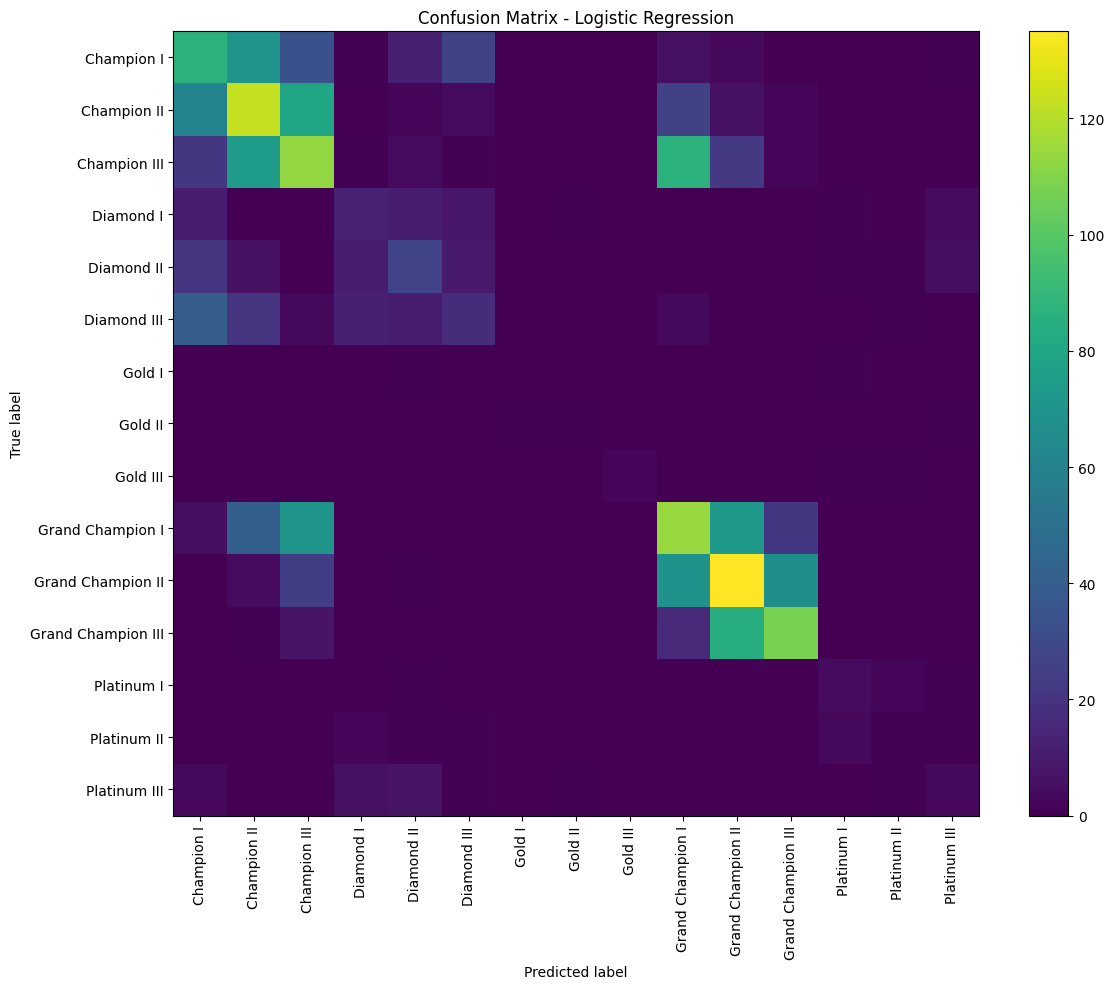

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# BEST FINAL MODEL
# =========================
best_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=3000, random_state=42))
])

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

# =========================
# CLASSIFICATION REPORT
# =========================
print("========================================")
print("Classification report - Best model")
print("========================================")
print(classification_report(y_test, y_pred, zero_division=0))

# También en DataFrame por si lo queréis guardar o mostrar mejor
report_dict = classification_report(y_test, y_pred, zero_division=0, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()

print("========================================")
print("Classification report as DataFrame")
print("========================================")
display(report_df)

# =========================
# CONFUSION MATRIX
# =========================
labels = best_model.classes_
cm = confusion_matrix(y_test, y_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

print("========================================")
print("Confusion matrix - Best model")
print("========================================")
display(cm_df)

# Visual opcional
plt.figure(figsize=(12, 10))
plt.imshow(cm, aspect="auto")
plt.xticks(range(len(labels)), labels, rotation=90)
plt.yticks(range(len(labels)), labels)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix - Logistic Regression")
plt.colorbar()
plt.tight_layout()
plt.show()

In [21]:
import optuna
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

# =========================
# OPTUNA FOR LOGISTIC REGRESSION
# =========================
def objective_lr(trial):
    C = trial.suggest_float("C", 1e-3, 100.0, log=True)
    solver = trial.suggest_categorical("solver", ["lbfgs", "saga"])
    class_weight = trial.suggest_categorical("class_weight", [None, "balanced"])

    clf = LogisticRegression(
        C=C,
        solver=solver,
        class_weight=class_weight,
        max_iter=5000,
        random_state=42
    )

    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", clf)
    ])

    scores = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring="f1_macro",
        n_jobs=-1
    )

    return scores.mean()

study_lr = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner()
)

study_lr.optimize(objective_lr, n_trials=30)

print("========================================")
print("Best Optuna trial")
print("========================================")
print("Best value (f1_macro):", study_lr.best_value)
print("Best params:", study_lr.best_params)

optuna_results_df = study_lr.trials_dataframe()
display(optuna_results_df.sort_values("value", ascending=False).head(10))

[I 2026-03-20 20:58:36,531] A new study created in memory with name: no-name-80474a7c-bc1d-4cee-8cb1-eefc727fb66f
[I 2026-03-20 20:58:40,959] Trial 0 finished with value: 0.25601766131261694 and parameters: {'C': 0.0745934328572655, 'solver': 'lbfgs', 'class_weight': None}. Best is trial 0 with value: 0.25601766131261694.
[I 2026-03-20 21:02:09,751] Trial 1 finished with value: 0.21070812352211235 and parameters: {'C': 0.0060252157362038605, 'solver': 'saga', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.25601766131261694.
[I 2026-03-20 21:02:12,400] Trial 2 finished with value: 0.1445735547323757 and parameters: {'C': 0.001267425589893723, 'solver': 'lbfgs', 'class_weight': None}. Best is trial 0 with value: 0.25601766131261694.
[I 2026-03-20 21:02:28,925] Trial 3 finished with value: 0.18534281413896275 and parameters: {'C': 0.008260808399079604, 'solver': 'saga', 'class_weight': None}. Best is trial 0 with value: 0.25601766131261694.
[I 2026-03-20 21:06:32,722] Trial 4 

Best Optuna trial
Best value (f1_macro): 0.2912299004840135
Best params: {'C': 1.504768872974941, 'solver': 'lbfgs', 'class_weight': None}


,number,value,datetime_start,datetime_complete,duration,params_C,params_class_weight,params_solver,state
28,28,0.291230,2026-03-20 21:15:29.340674,2026-03-20 21:15:33.243818,0 days 00:00:03.903144,1.504769,None,lbfgs,COMPLETE
23,23,0.285713,2026-03-20 21:15:01.193508,2026-03-20 21:15:07.883992,0 days 00:00:06.690484,26.939266,None,lbfgs,COMPLETE
25,25,0.285283,2026-03-20 21:15:14.503273,2026-03-20 21:15:19.669593,0 days 00:00:05.166320,4.272234,None,lbfgs,COMPLETE
12,12,0.284603,2026-03-20 21:14:03.051400,2026-03-20 21:14:09.792447,0 days 00:00:06.741047,78.208266,None,lbfgs,COMPLETE
22,22,0.284364,2026-03-20 21:14:55.940346,2026-03-20 21:15:01.192222,0 days 00:00:05.251876,4.458350,None,lbfgs,COMPLETE
16,16,0.284284,2026-03-20 21:14:24.555957,2026-03-20 21:14:30.925364,0 days 00:00:06.369407,27.191932,None,lbfgs,COMPLETE
21,21,0.284122,2026-03-20 21:14:50.783100,2026-03-20 21:14:55.938337,0 days 00:00:05.155237,5.261380,None,lbfgs,COMPLETE
7,7,0.283959,2026-03-20 21:09:05.259487,2026-03-20 21:09:11.185984,0 days 00:00:05.926497,11.015057,None,lbfgs,COMPLETE
14,14,0.283942,2026-03-20 21:14:16.368581,2026-03-20 21:14:22.409615,0 days 00:00:06.041034,13.271695,None,lbfgs,COMPLETE
17,17,0.283707,2026-03-20 21:14:30.929350,2026-03-20 21:14:37.806722,0 days 00:00:06.877372,34.237975,None,lbfgs,COMPLETE
